## WOrking with Langchain and Langgraph

In [ ]:
!pip install langchain langchain_openai langchain_core langchain_community --quiet

In [1]:
# how to load a model with langchain
from langchain.chat_models import init_chat_model
model = init_chat_model("azure_openai:gpt-4o-mini")

model.invoke("Write a python code to print Hello World, keep it short. ")

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


AIMessage(content='Certainly! Here’s a short Python code to print "Hello World":\n\n```python\nprint("Hello World")\n```', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 21, 'total_tokens': 45, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f97eff32c5', 'id': 'chatcmpl-DCfBlguy1OWQtLKPECwlxeR73wMfP', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None,

In [ ]:
# chatprompt template
from langchain_core.prompts import ChatPromptTemplate
prompt_temp = ChatPromptTemplate([("system","You are a translator to translate to language {lang}"),
                                  ("user","Translate: {text_input}")])
prompt_temp

In [ ]:
prompt_temp.invoke({"lang":"French","text_input":"Hi Good Morning!"})

In [ ]:
out = model.invoke(prompt_temp.invoke({"lang":"French","text_input":"Hi Good Morning!"}))
out

In [8]:
# parser
from langchain_core.output_parsers import StrOutputParser
parser = StrOutputParser()
parser.invoke(out)

'Bonjour, bonne matinée !'

## Workflow (chain) using Langchain

In [ ]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

model = init_chat_model("azure_openai:gpt-4o-mini")
parser = StrOutputParser()

prompt = ChatPromptTemplate([("system","You are a translator to translate to language {lang}"),("user","{text_input}")])

# chain/workflow

workflow = prompt | model | parser
workflow.invoke({"lang":"hindi","text_input":"Hi, Good Morning. Hope you are doing well."})

'नमस्ते, शुभ प्रभात। आशा है कि आप अच्छे होंगे।'

In [ ]:
# code writer
cw_prompt = ChatPromptTemplate([("system","You write python code for a given task, only provide code,"),("user","{task}")])
code_writer = cw_prompt | model | parser
pycode = code_writer.invoke({"task":"fibonacci series"})
print(pycode)

In [ ]:
# code enhancer
ce_prompt = ChatPromptTemplate([("system","""You only add comments, docstrings and test cases in docstring to
                                  any python code provided. You must not change the code. """),("user","{code}")])
code_enhancer = ce_prompt | model | parser
print(code_enhancer.invoke({"code":pycode}))

In [17]:
def schema_match(code):
    return {"code":code}

In [19]:
final_wf = code_writer | schema_match | code_enhancer
print(final_wf.invoke({"task":"fibonacci series"}))

```python
def fibonacci(n):
    """
    Generate a list of Fibonacci numbers up to the n-th number.

    The Fibonacci sequence is defined as follows:
    - F(0) = 0
    - F(1) = 1
    - F(n) = F(n-1) + F(n-2) for n > 1

    Args:
    n (int): The number of Fibonacci numbers to generate.

    Returns:
    list: A list containing the first n Fibonacci numbers.

    Example:
    >>> fibonacci(10)
    [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
    """
    fib_series = [0, 1]
    for i in range(2, n):
        next_value = fib_series[-1] + fib_series[-2]
        fib_series.append(next_value)
    return fib_series[:n]

# Example usage: Print the first 10 Fibonacci numbers
print(fibonacci(10))
```


## LangGraph Graph API

In [ ]:
!pip install langgraph --quiet

In [28]:
# A Data Model (State)
from typing import TypedDict

class mystate(TypedDict):
    lang:str
    text_input:str
    output:str

In [32]:
# translation node
def translation(state:mystate)->mystate:
    prompt = ChatPromptTemplate([("system","You translate any text to lang {lang}"),
                                 ("user","{text_input}")])
    resp = model.invoke(prompt.invoke({"lang":state['lang'],"text_input":state['text_input']}))
    return {"output":resp.content}

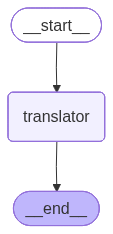

In [33]:
# create Graph
from langgraph.graph import StateGraph,START,END
builder = StateGraph(mystate)
builder.add_node("translator",translation)
builder.add_edge(START,"translator")
builder.add_edge("translator",END)
graph = builder.compile()
graph

In [35]:
out = graph.invoke({"lang":"french","text_input":"Hello World"})
out

{'lang': 'french', 'text_input': 'Hello World', 'output': 'Bonjour le monde'}

In [36]:
out['output']

'Bonjour le monde'